In [10]:
import pandas as pd
import numpy as np

In [11]:
df = pd.read_csv("dataset_20k.csv")
df

,themes,solution,epd,rating,rating_dev,to_move,cp_eval,move1cp,nodes,move1multiPV,...,dovetailMate,triangleMate,balestraMate,collinearMove,killBoxMate,anastasiaMate,blindSwineMate,castling,mateIn5,underPromotion
0,crushing hangingPiece long middlegame,f2g3 e6e7 b2b1 b3c1 b1c1 h6c1,r6k/pp2r2p/4Rp1Q/3p4/8/1N1P2b1/PqP3PP/7K w - -,1935,76,1,790,811,1542389,1,...,0,0,0,0,0,0,0,0,0,0
1,advantage endgame short,d3d6 f8d8 d6d8 f6d8,5rk1/1p3ppp/pq1Q1b2/8/8/1P3N2/P4PPP/3R2K1 b - -,1414,75,-1,477,494,298744,1,...,0,0,0,0,0,0,0,0,0,0
2,advantage endgame rookEndgame short,e7f7 f5e5 e2f1 e5e6,8/5R2/1p2P3/p4r2/P6p/1P3Pk1/4K3/8 b - -,1385,80,-1,288,317,320925,1,...,0,0,0,0,0,0,0,0,0,0
3,advantage middlegame short,b6c5 e2g4 h3g4 d1g4,r2qr1k1/b1p2ppp/p5n1/P1p1p3/4P1n1/B2P2Pb/3NBP1...,1084,74,1,280,282,139540,1,...,0,0,0,0,0,0,0,0,0,0
4,crushing endgame fork short,e4d2 d4e2 g1f1 e2c3,6k1/5p1p/4p3/4q3/3n4/2Q3P1/PP1N1P1P/6K1 b - -,1550,75,-1,527,539,153534,1,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19800,advantage endgame short skewer,b2b6 a7a8 c8d7 a8f8,2k2r2/R7/1r2p3/p2p4/P4Bp1/6P1/5P1P/6K1 w - -,1553,75,1,368,352,174705,1,...,0,0,0,0,0,0,0,0,0,0
19801,kingsideAttack master mate mateIn1 middlegame ...,d1f1 f8f1,2kb1r2/1p5N/4p3/p2pP1p1/2p3P1/P1Pn2Bp/1P1R3P/5...,483,104,-1,-1500,-1500,54018,1,...,0,0,0,0,0,0,0,0,0,0
19802,kingsideAttack mate mateIn1 middlegame oneMove,f7f5 h6h7,r1bq1rk1/p2n3p/4p1pQ/3pPp2/5P2/2PpB2R/P1P3PP/R...,745,89,1,1500,1500,65940,1,...,0,0,0,0,0,0,0,0,0,0
19803,endgame mate mateIn1 oneMove rookEndgame,g5g4 a6g6,8/8/R7/5p1p/P5k1/3r2P1/6K1/8 w - -,662,124,1,1500,1500,49200,1,...,0,0,0,0,0,0,0,0,0,0


In [18]:
for c in df.select_dtypes(exclude=["int", "float"]).columns:
    print(c)

themes
solution
epd


In [20]:
y = df["rating"]

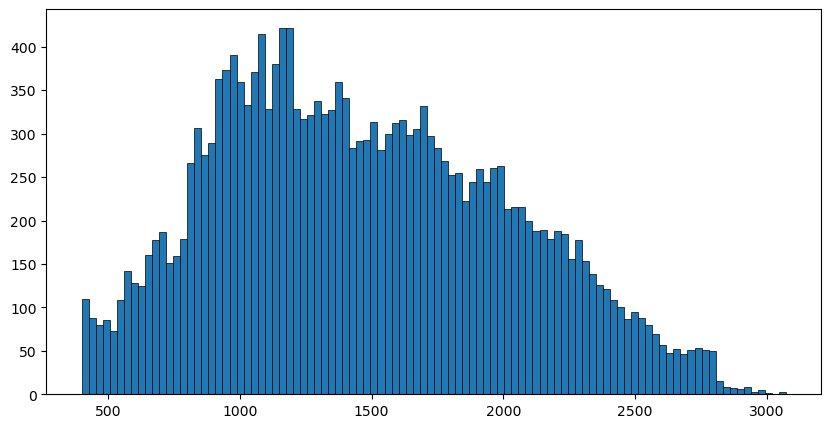

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.hist(y, bins=100, edgecolor="black", linewidth=0.5)
plt.show()

In [21]:
X = df.drop(columns=["themes", "solution", "epd", "rating_dev", "rating"])
X

,to_move,cp_eval,move1cp,nodes,move1multiPV,move1sel_depth,move1w,move1d,move1l,move2cp,...,dovetailMate,triangleMate,balestraMate,collinearMove,killBoxMate,anastasiaMate,blindSwineMate,castling,mateIn5,underPromotion
0,1,790,811,1542389,1,48,1000,0,0,-557,...,0,0,0,0,0,0,0,0,0,0
1,-1,477,494,298744,1,30,1000,0,0,25,...,0,0,0,0,0,0,0,0,0,0
2,-1,288,317,320925,1,37,1000,0,0,-328,...,0,0,0,0,0,0,0,0,0,0
3,1,280,282,139540,1,42,999,1,0,-99,...,0,0,0,0,0,0,0,0,0,0
4,-1,527,539,153534,1,38,1000,0,0,-290,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19800,1,368,352,174705,1,23,1000,0,0,-75,...,0,0,0,0,0,0,0,0,0,0
19801,-1,-1500,-1500,54018,1,2,1000,0,0,-300,...,0,0,0,0,0,0,0,0,0,0
19802,1,1500,1500,65940,1,2,1000,0,0,-202,...,0,0,0,0,0,0,0,0,0,0
19803,1,1500,1500,49200,1,2,1000,0,0,-8,...,0,0,0,0,0,0,0,0,0,0


In [113]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=67)
print(X_train.shape)
print(Y_train.shape)
print(X_test.shape)
print(Y_test.shape)

(13863, 50)
(13863,)
(5942, 50)
(5942,)


In [41]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import mean_absolute_error as MSE

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(f"MAE: {MSE(y_test, y_pred)}")

TypeError: ForestClassifier.predict() takes 2 positional arguments but 3 were given

In [119]:
from xgboost import XGBRegressor
model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    eval_metric="mae"
)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(f"MAE: {MSE(y_test, y_pred)}")

MAE: 293.1119079589844


In [82]:
from sklearn.feature_selection import mutual_info_regression

mi_scores = mutual_info_regression(X_train, y_train)

In [94]:
best_features_mi = {name: round(float(mi_scores[i]), 4) for i, name in enumerate(X.columns.values)}
best_features_mi = dict(sorted(d.items(), key=lambda item: item[1], reverse=True))
best_features_mi

{'move1sel_depth': 0.1918,
 'cp_eval': 0.1765,
 'move1cp': 0.1752,
 'mate': 0.1572,
 'mateIn1': 0.1021,
 'oneMove': 0.0995,
 'nodes': 0.0719,
 'long': 0.0626,
 'veryLong': 0.048,
 'crushing': 0.0445,
 'mateIn2': 0.0421,
 'move2cp': 0.0389,
 'backRankMate': 0.0387,
 'total_material': 0.0366,
 'advantage': 0.0363,
 'white_material': 0.0353,
 'black_material': 0.0319,
 'defensiveMove': 0.03,
 'move2w': 0.0253,
 'move3cp': 0.0235,
 'quietMove': 0.0233,
 'short': 0.022,
 'move1w': 0.0208,
 'move2sel_depth': 0.0175,
 'orig_w': 0.0161,
 'move2d': 0.0149,
 'move3l': 0.0136,
 'attraction': 0.0122,
 'move1d': 0.0119,
 'material_balance': 0.0119,
 'move3w': 0.0114,
 'black_p': 0.0111,
 'kingsideAttack': 0.0108,
 'sacrifice': 0.0104,
 'pin': 0.0099,
 'orig_d': 0.0098,
 'smotheredMate': 0.0098,
 'white_P': 0.0097,
 'black_r': 0.0096,
 'move3d': 0.0094,
 'move2l': 0.009,
 'fork': 0.0088,
 'exposedKing': 0.0082,
 'trappedPiece': 0.0082,
 'white_Q': 0.0079,
 'rookEndgame': 0.0078,
 'underPromotion': 0

In [115]:
choose_features = list(best_features_mi.keys())[75:]
choose_features

['queenRookEndgame',
 'interference',
 'orig_l',
 'endgame',
 'pawnEndgame',
 'black_n',
 'enPassant',
 'mateIn3',
 'vukovicMate',
 'black_k',
 'attackingF2F7',
 'discoveredCheck',
 'discoveredAttack',
 'triangleMate',
 'xRayAttack',
 'move3sel_depth',
 'white_B',
 'white_R',
 'white_K',
 'black_b',
 'hangingPiece',
 'master',
 'zugzwang',
 'skewer',
 'bishopEndgame',
 'advancedPawn',
 'promotion',
 'queensideAttack',
 'cornerMate',
 'intermezzo',
 'pillsburysMate',
 'hookMate',
 'doubleBishopMate',
 'epauletteMate',
 'killBoxMate',
 'anastasiaMate',
 'castling',
 'mateIn5']

In [120]:
X = df.drop(columns=["themes", "solution", "epd", "rating_dev", "rating"])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=67)

In [155]:
# https://scikit-learn.org/stable/developers/develop.html
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.tree import DecisionTreeRegressor

from sklearn.preprocessing import KBinsDiscretizer

class HierarchicalEnsembleRegressor(RegressorMixin, BaseEstimator):
    def __init__(self, main_model, submodels, bin_overlap=0.0):
        self.main_model = main_model
        self.submodels = submodels
        self.bin_overlap = bin_overlap
        
    def fit(self, X, y):
        X = X.values if hasattr(X, "values") else np.array(X)
        y = y.values if hasattr(y, "values") else np.array(y)

        self.y_min = np.min(y)
        self.y_max = np.max(y)
        X_bins, y_bins = self.get_bins(X, y)

        for i, c in enumerate(zip(X_bins, y_bins)):
            X_bin, y_bin = c
            self.submodels[i].fit(X_bin, y_bin)

        y_bin = self.target_to_bin(y)
        self.main_model.fit(X, y_bin)
    
    def predict(self, X):
        X = X.values if hasattr(X, "values") else np.array(X)
        
        y_bin_pred = self.main_model.predict(X)
        final_pred = np.zeros(len(X))
    
        for i in range(len(self.submodels)):
            mask = (y_bin_pred == i)
            if np.any(mask):
                final_pred[mask] = self.submodels[i].predict(X[mask])
            
        return final_pred

    def get_bins(self, X, y):
        N = len(self.submodels)
        width = (self.y_max - self.y_min) / N
    
        i_max = np.floor(((y - self.y_min) + self.bin_overlap) / width).astype(int)
        i_min = np.ceil(((y - self.y_min) - width - self.bin_overlap) / width).astype(int)
        i_min = np.clip(i_min, 0, N - 1)
        i_max = np.clip(i_max, 0, N - 1)
        
        X_bins = [[] for _ in range(N)]
        y_bins = [[] for _ in range(N)]
        
        for j in range(len(y)):
            for b in range(i_min[j], i_max[j] + 1):
                X_bins[b].append(X[j])
                y_bins[b].append(y[j])
    
        X_bins = [np.array(b) for b in X_bins]
        y_bins = [np.array(b) for b in y_bins]
        
        return X_bins, y_bins

    def target_to_bin(self, y):
        N = len(self.submodels)
        width = (self.y_max - self.y_min) / N
        bins = np.floor((y - self.y_min) / width).astype(int)
        return np.clip(bins, 0, N - 1)
        

In [162]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression

In [217]:
bins = 4
main_model = HistGradientBoostingClassifier(
    max_iter=100,
    max_depth=5,
    learning_rate=0.1, 
    categorical_features=None
)

submodels = [XGBRegressor(n_estimators=100, learning_rate=0.1, eval_metric="mae") for _ in range(bins)]

In [221]:
model = HierarchicalEnsembleRegressor(main_model, submodels, bin_overlap=200)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(f"MAE: {MSE(y_test, y_pred)}")

MAE: 307.043283714826


In [222]:
y_true_bins = model.target_to_bin(y_test)

In [223]:
from collections import Counter 
counts = Counter(y_true_bins)
total = sum(counts.values())

{b: round(c / total, 2) for b, c in counts.items()}

{1: 0.41, 3: 0.06, 2: 0.26, 0: 0.26}

In [224]:
y_pred_bins = model.main_model.predict(X_test)

C:\Users\Matej\.conda\envs\chess-ai\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but HistGradientBoostingClassifier was fitted without feature names
  warnings.warn(


In [225]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [226]:
acc = accuracy_score(y_true_bins, y_pred_bins)
print(f"Router Accuracy: {acc:.2%}")

print(classification_report(y_true_bins, y_pred_bins))

Router Accuracy: 56.60%
              precision    recall  f1-score   support

           0       0.66      0.65      0.66      1547
           1       0.55      0.63      0.58      2465
           2       0.51      0.48      0.50      1568
           3       0.46      0.15      0.23       362

    accuracy                           0.57      5942
   macro avg       0.54      0.48      0.49      5942
weighted avg       0.56      0.57      0.56      5942

